# 🚚 AGV 倉庫路線規劃系統 (Ant Colony Optimization)

本系統使用螞蟻演算法(ACO)為多輛AGV在倉庫環境中規劃最優路線，包含：
- 倉庫佈局載入與座標對齊
- BFS路徑規劃與碰撞避免
- 螞蟻演算法優化
- 完整的視覺化展示
- Flexsim匯出功能

## 📦 導入必要套件

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from collections import defaultdict, deque
from typing import List, Tuple, Dict, Optional
import math
import random
import heapq
import json

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("📦 套件載入完成")

📦 套件載入完成


## 🏢 倉庫類別定義

In [2]:
class Warehouse:
    """
    倉庫類別：管理倉庫佈局、儲位資訊和路徑規劃
    """
    def __init__(self, layout_df: pd.DataFrame, storage_map: Dict, 
                 item_to_locations: Dict, storage_grid: np.ndarray, map_mask: np.ndarray):
        self.layout_df = layout_df
        self.storage_map = storage_map  # (x,y) -> item_name
        self.item_to_locations = item_to_locations  # item_name -> [(x,y), ...]
        self.storage_grid = storage_grid
        self.map_mask = map_mask  # 1=可行走, 0=障礙物
        self.rows, self.cols = map_mask.shape
    
    def is_walkable(self, x: int, y: int) -> bool:
        """檢查座標是否可行走"""
        return (0 <= x < self.cols and 0 <= y < self.rows and 
                self.map_mask[y, x] == 1)
    
    def get_neighbors(self, x: int, y: int) -> List[Tuple[int, int]]:
        """獲取可行走的相鄰座標"""
        neighbors = []
        for dx, dy in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            new_x, new_y = x + dx, y + dy
            if self.is_walkable(new_x, new_y):
                neighbors.append((new_x, new_y))
        return neighbors
    
    def bfs_path(self, start: Tuple[int, int], goal: Tuple[int, int], 
                 occupied_positions: set = None) -> Optional[List[Tuple[int, int]]]:
        """使用BFS尋找路徑，避開已佔用位置"""
        if occupied_positions is None:
            occupied_positions = set()
        
        if not self.is_walkable(start[0], start[1]) or not self.is_walkable(goal[0], goal[1]):
            return None
        
        if start in occupied_positions or goal in occupied_positions:
            return None
            
        queue = deque([(start, [start])])
        visited = {start}
        
        while queue:
            (x, y), path = queue.popleft()
            
            if (x, y) == goal:
                return path
            
            for next_x, next_y in self.get_neighbors(x, y):
                if (next_x, next_y) not in visited and (next_x, next_y) not in occupied_positions:
                    visited.add((next_x, next_y))
                    queue.append(((next_x, next_y), path + [(next_x, next_y)]))
        
        return None

print("🏢 倉庫類別定義完成")

🏢 倉庫類別定義完成


## 📂 倉庫佈局載入函數

In [3]:
def load_warehouse_from_csv(csv_file='warehouse.csv') -> Warehouse:
    """
    從CSV檔案載入倉庫佈局並建立Warehouse物件
    - CSV中 0=通道, 數字=貨品編號
    - MapMask中 1=可行走, 0=障礙物
    """
    print(f"📂 正在載入倉庫佈局: {csv_file}")
    
    # 載入CSV佈局
    df_layout = pd.read_csv(csv_file, header=None)
    print(f"   CSV佈局形狀: {df_layout.shape}")
    
    # 載入MapMask
    map_mask = pd.read_csv('MapMask_preview.csv', header=None).values
    print(f"   MapMask形狀: {map_mask.shape}")
    
    # 驗證形狀一致性
    if df_layout.shape != map_mask.shape:
        raise ValueError(f"形狀不匹配: CSV {df_layout.shape} vs MapMask {map_mask.shape}")
    
    # 建立儲位對應表
    storage_map = {}
    item_to_locations = defaultdict(list)
    storage_grid = np.zeros_like(df_layout, dtype=int)
    
    cargo_count = 0
    walkway_count = 0
    
    # 使用正確偏移量 (0, 0)
    offset_x, offset_y = 0, 0
    
    for y in range(df_layout.shape[0]):
        for x in range(df_layout.shape[1]):
            val = df_layout.iat[y, x]
            if val == 0:
                walkway_count += 1
            else:
                # 貨品位置
                item_name = str(int(val))
                storage_map[(x, y)] = item_name
                item_to_locations[item_name].append((x, y))
                storage_grid[y, x] = 1
                cargo_count += 1
    
    print(f"   ✅ 載入完成: {len(item_to_locations)} 種貨品, {cargo_count} 個儲位, {walkway_count} 個通道")
    print(f"   ✅ 使用座標偏移量: ({offset_x}, {offset_y})")
    
    return Warehouse(df_layout, storage_map, item_to_locations, storage_grid, map_mask)

print("📂 倉庫載入函數定義完成")

📂 倉庫載入函數定義完成


## 🎯 智慧取貨位置生成

In [4]:
def find_accessible_position(cargo_pos: Tuple[int, int], map_mask: np.ndarray) -> Tuple[int, int]:
    """
    找到貨品位置旁邊的可行走位置
    AGV無法直接到達貨品位置（障礙物），需要到相鄰的可行走位置
    """
    x, y = cargo_pos
    
    # 檢查四個相鄰位置（上下左右）
    directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]  # 上、下、左、右
    
    for dx, dy in directions:
        new_x, new_y = x + dx, y + dy
        if (0 <= new_x < map_mask.shape[1] and 
            0 <= new_y < map_mask.shape[0] and
            map_mask[new_y, new_x] == 1):  # 可行走區域
            return (new_x, new_y)
    
    # 如果四個相鄰位置都不可行走，檢查對角線位置
    diagonals = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    for dx, dy in diagonals:
        new_x, new_y = x + dx, y + dy
        if (0 <= new_x < map_mask.shape[1] and 
            0 <= new_y < map_mask.shape[0] and
            map_mask[new_y, new_x] == 1):
            return (new_x, new_y)
    
    raise ValueError(f"找不到貨品位置{cargo_pos}的可行走相鄰位置")

def generate_order_locations(order: List[str],
                           item_to_locations: Dict[str, List[Tuple[int,int]]],
                           map_mask: np.ndarray,
                           start_point: Tuple[int,int]=(15,0)) -> List[Tuple[int,int]]:
    """
    為訂單生成AGV可到達的取貨位置
    選擇距離起點最近且未被使用的位置
    """
    used_coords = set()
    coords = []
    used_by_item = defaultdict(set)

    for item in order:
        if item not in item_to_locations:
            raise ValueError(f"品項 {item} 不存在於倉庫中")
            
        cargo_candidates = [loc for loc in item_to_locations[item]
                           if loc not in used_by_item[item]]
        
        if not cargo_candidates:
            raise ValueError(f"品項 {item} 缺可用儲位")
        
        # 為每個候選貨品位置找到可行走的相鄰位置
        accessible_candidates = []
        for cargo_pos in cargo_candidates:
            try:
                accessible_pos = find_accessible_position(cargo_pos, map_mask)
                if accessible_pos not in used_coords:
                    accessible_candidates.append((accessible_pos, cargo_pos))
            except ValueError:
                continue  # 這個貨品位置無法到達，跳過
        
        if not accessible_candidates:
            raise ValueError(f"品項 {item} 沒有可到達的儲位")
        
        # 選擇距離起點最近的可行走位置
        chosen_accessible, chosen_cargo = min(accessible_candidates,
                                            key=lambda x: math.hypot(x[0][0]-start_point[0], 
                                                                   x[0][1]-start_point[1]))
        
        coords.append(chosen_accessible)
        used_coords.add(chosen_accessible)
        used_by_item[item].add(chosen_cargo)
    
    return coords

print("🎯 智慧取貨位置生成函數定義完成")

🎯 智慧取貨位置生成函數定義完成


## 🐜 螞蟻演算法 TSP 優化

In [5]:
class SimpleACO:
    """
    簡化版螞蟻演算法用於解決TSP問題
    優化AGV訪問多個取貨點的順序
    """
    def __init__(self, coords: List[Tuple[int,int]], start=(15,0),
                 n_ants=10, n_iter=100, alpha=1, beta=5, evaporation=0.5, q=100):
        self.start = start
        self.coords = coords  # 不包含起點
        self.n = len(coords)
        self.n_ants = n_ants
        self.n_iter = n_iter
        self.alpha = alpha  # 費洛蒙重要性
        self.beta = beta    # 距離重要性
        self.evaporation = evaporation
        self.q = q
        
        # 計算距離矩陣（包含起點）
        all_points = [start] + coords
        self.distances = np.zeros((len(all_points), len(all_points)))
        for i, p1 in enumerate(all_points):
            for j, p2 in enumerate(all_points):
                self.distances[i][j] = math.hypot(p1[0]-p2[0], p1[1]-p2[1])
        
        # 初始化費洛蒙矩陣
        self.pheromones = np.ones((len(all_points), len(all_points)))
        
        self.best_path = None
        self.best_distance = float('inf')
    
    def solve(self) -> Tuple[List[int], float]:
        """執行螞蟻演算法求解"""
        for iteration in range(self.n_iter):
            # 所有螞蟻構建解
            all_paths = []
            all_distances = []
            
            for ant in range(self.n_ants):
                path, distance = self._construct_solution()
                all_paths.append(path)
                all_distances.append(distance)
                
                # 更新最佳解
                if distance < self.best_distance:
                    self.best_distance = distance
                    self.best_path = path.copy()
            
            # 更新費洛蒙
            self._update_pheromones(all_paths, all_distances)
        
        return self.best_path, self.best_distance
    
    def _construct_solution(self) -> Tuple[List[int], float]:
        """單隻螞蟻構建解"""
        current = 0  # 從起點開始
        unvisited = set(range(1, self.n + 1))  # 待訪問的點（不包含起點）
        path = [current]
        total_distance = 0
        
        while unvisited:
            next_city = self._select_next_city(current, unvisited)
            path.append(next_city)
            total_distance += self.distances[current][next_city]
            current = next_city
            unvisited.remove(next_city)
        
        # 返回起點
        path.append(0)
        total_distance += self.distances[current][0]
        
        return path, total_distance
    
    def _select_next_city(self, current: int, unvisited: set) -> int:
        """選擇下一個城市"""
        probabilities = []
        
        for city in unvisited:
            pheromone = self.pheromones[current][city] ** self.alpha
            visibility = (1.0 / max(self.distances[current][city], 0.001)) ** self.beta
            probabilities.append(pheromone * visibility)
        
        # 轉換為機率分布
        total = sum(probabilities)
        if total == 0:
            return random.choice(list(unvisited))
        
        probabilities = [p / total for p in probabilities]
        
        # 輪盤選擇
        r = random.random()
        cumulative = 0
        cities = list(unvisited)
        
        for i, prob in enumerate(probabilities):
            cumulative += prob
            if r <= cumulative:
                return cities[i]
        
        return cities[-1]
    
    def _update_pheromones(self, all_paths: List[List[int]], all_distances: List[float]):
        """更新費洛蒙"""
        # 蒸發
        self.pheromones *= (1 - self.evaporation)
        
        # 添加新費洛蒙
        for path, distance in zip(all_paths, all_distances):
            pheromone_deposit = self.q / distance
            for i in range(len(path) - 1):
                from_city = path[i]
                to_city = path[i + 1]
                self.pheromones[from_city][to_city] += pheromone_deposit
                self.pheromones[to_city][from_city] += pheromone_deposit

print("🐜 螞蟻演算法類別定義完成")

🐜 螞蟻演算法類別定義完成


## 🎯 ACO 動態任務分配系統

In [ ]:
class ACOTaskAllocator:
    """
    使用螞蟻演算法為多台AGV分配任務的最佳化系統
    將所有任務透過ACO分配給AGV，使總makespan最小化
    """
    def __init__(self, num_agvs=3, n_ants=20, n_iter=100, alpha=1.0, beta=2.0, 
                 rho=0.1, max_items_per_trip=5):
        self.num_agvs = num_agvs
        self.n_ants = n_ants
        self.n_iter = n_iter
        self.alpha = alpha  # 費洛蒙重要性
        self.beta = beta    # 啟發式資訊重要性
        self.rho = rho      # 費洛蒙揮發率
        self.max_items_per_trip = max_items_per_trip
        
    def allocate_tasks(self, all_task_items: List[str], warehouse: Warehouse, 
                      depot: Tuple[int, int] = (15, 0)) -> Dict:
        """
        使用ACO將所有任務項目分配給多台AGV
        
        參數:
        - all_task_items: 所有需要撿取的物品列表
        - warehouse: 倉庫物件
        - depot: AGV起始位置
        
        返回:
        - 包含每台AGV分配任務的字典
        """
        print(f"🎯 開始使用ACO分配 {len(all_task_items)} 個任務給 {self.num_agvs} 台AGV...")
        
        # 生成所有任務的取貨位置
        task_locations = self._generate_all_task_locations(
            all_task_items, warehouse, depot
        )
        
        print(f"   ✅ 生成了 {len(task_locations)} 個任務取貨位置")
        
        # 計算任務間距離矩陣
        distances = self._calculate_distance_matrix(task_locations, depot)
        
        # 使用ACO找到最佳任務分配
        best_allocation = self._run_aco_allocation(
            task_locations, distances, depot
        )
        
        return best_allocation
    
    def _generate_all_task_locations(self, all_items: List[str], 
                                   warehouse: Warehouse, depot: Tuple[int, int]) -> List[Tuple[int, int]]:
        """為所有任務項目生成取貨位置"""
        task_locations = []
        used_positions = set()
        
        for item in all_items:
            if item not in warehouse.item_to_locations:
                print(f"⚠️  警告: 物品 {item} 不存在於倉庫中")
                continue
                
            # 找到該物品的可用位置
            available_positions = []
            for cargo_pos in warehouse.item_to_locations[item]:
                try:
                    accessible_pos = find_accessible_position(cargo_pos, warehouse.map_mask)
                    if accessible_pos not in used_positions:
                        available_positions.append(accessible_pos)
                except ValueError:
                    continue
            
            if available_positions:
                # 選擇距離depot最近的位置
                best_pos = min(available_positions,
                             key=lambda pos: math.hypot(pos[0]-depot[0], pos[1]-depot[1]))
                task_locations.append(best_pos)
                used_positions.add(best_pos)
            else:
                print(f"⚠️  警告: 物品 {item} 無可用取貨位置")
        
        return task_locations
    
    def _calculate_distance_matrix(self, task_locations: List[Tuple[int, int]], 
                                 depot: Tuple[int, int]) -> np.ndarray:
        """計算包含depot的距離矩陣"""
        all_locations = [depot] + task_locations
        n = len(all_locations)
        distances = np.zeros((n, n))
        
        for i in range(n):
            for j in range(n):
                if i != j:
                    distances[i][j] = math.hypot(
                        all_locations[i][0] - all_locations[j][0],
                        all_locations[i][1] - all_locations[j][1]
                    )
        
        return distances
    
    def _run_aco_allocation(self, task_locations: List[Tuple[int, int]], 
                          distances: np.ndarray, depot: Tuple[int, int]) -> Dict:
        """執行ACO任務分配演算法"""
        n_tasks = len(task_locations)
        if n_tasks == 0:
            return {f'AGV-{i+1}': [] for i in range(self.num_agvs)}
        
        # 初始化費洛蒙矩陣
        pheromones = np.ones((n_tasks + 1, self.num_agvs))  # +1 for depot
        
        best_makespan = float('inf')
        best_allocation = None
        
        print(f"   🐜 執行 {self.n_iter} 次ACO迭代...")
        
        for iteration in range(self.n_iter):
            # 所有螞蟻構建解
            ant_allocations = []
            ant_makespans = []
            
            for ant in range(self.n_ants):
                allocation = self._construct_allocation_solution(
                    n_tasks, distances, pheromones
                )
                makespan = self._calculate_makespan(allocation, distances)
                
                ant_allocations.append(allocation)
                ant_makespans.append(makespan)
                
                # 更新最佳解
                if makespan < best_makespan:
                    best_makespan = makespan
                    best_allocation = allocation.copy()
            
            # 更新費洛蒙
            self._update_pheromones(pheromones, ant_allocations, ant_makespans)
            
            if iteration % 20 == 0:
                print(f"      迭代 {iteration}: 當前最佳makespan = {best_makespan:.2f}")
        
        # 轉換為輸出格式
        result = self._format_allocation_result(
            best_allocation, task_locations, best_makespan
        )
        
        print(f"   ✅ ACO分配完成! 最佳makespan: {best_makespan:.2f}")
        return result
    
    def _construct_allocation_solution(self, n_tasks: int, distances: np.ndarray, 
                                     pheromones: np.ndarray) -> Dict:
        """單隻螞蟻構建任務分配解"""
        allocation = {i: [] for i in range(self.num_agvs)}
        unassigned_tasks = list(range(1, n_tasks + 1))  # 排除depot(0)
        agv_loads = [0] * self.num_agvs  # 每台AGV當前負載
        
        while unassigned_tasks:
            # 為每個未分配任務選擇AGV
            task = random.choice(unassigned_tasks)
            
            # 計算每台AGV接受此任務的機率
            probabilities = []
            for agv_id in range(self.num_agvs):
                if agv_loads[agv_id] >= self.max_items_per_trip:
                    probabilities.append(0.0)  # 超載，不能分配
                else:
                    # 考慮費洛蒙和啟發式資訊
                    pheromone = pheromones[task][agv_id] ** self.alpha
                    
                    # 啟發式：基於當前AGV負載和任務距離
                    if allocation[agv_id]:
                        last_task = allocation[agv_id][-1]
                        heuristic = (1.0 / max(distances[last_task][task], 0.001)) ** self.beta
                    else:
                        heuristic = (1.0 / max(distances[0][task], 0.001)) ** self.beta  # 從depot開始
                    
                    # 負載平衡因子
                    load_factor = 1.0 / (1.0 + agv_loads[agv_id])
                    
                    probabilities.append(pheromone * heuristic * load_factor)
            
            # 輪盤選擇AGV
            total_prob = sum(probabilities)
            if total_prob == 0:
                # 所有AGV都超載，強制分配給負載最輕的AGV
                chosen_agv = min(range(self.num_agvs), key=lambda x: agv_loads[x])
            else:
                probabilities = [p / total_prob for p in probabilities]
                chosen_agv = np.random.choice(self.num_agvs, p=probabilities)
            
            # 分配任務
            allocation[chosen_agv].append(task)
            agv_loads[chosen_agv] += 1
            unassigned_tasks.remove(task)
        
        return allocation
    
    def _calculate_makespan(self, allocation: Dict, distances: np.ndarray) -> float:
        """計算分配方案的makespan"""
        agv_times = []
        
        for agv_id in range(self.num_agvs):
            if not allocation[agv_id]:
                agv_times.append(0.0)
                continue
            
            # 計算此AGV的總路徑時間
            total_time = 0.0
            current_pos = 0  # 從depot開始
            
            for task in allocation[agv_id]:
                total_time += distances[current_pos][task]
                current_pos = task
            
            # 回到depot
            total_time += distances[current_pos][0]
            agv_times.append(total_time)
        
        return max(agv_times) if agv_times else 0.0
    
    def _update_pheromones(self, pheromones: np.ndarray, allocations: List[Dict], 
                          makespans: List[float]):
        """更新費洛蒙矩陣"""
        # 揮發
        pheromones *= (1 - self.rho)
        
        # 添加新費洛蒙
        for allocation, makespan in zip(allocations, makespans):
            if makespan > 0:
                pheromone_deposit = 1.0 / makespan
                
                for agv_id in range(self.num_agvs):
                    for task in allocation[agv_id]:
                        pheromones[task][agv_id] += pheromone_deposit
    
    def _format_allocation_result(self, allocation: Dict, task_locations: List[Tuple[int, int]], 
                                makespan: float) -> Dict:
        """格式化分配結果"""
        result = {
            'agv_tasks': {},
            'task_locations': task_locations,
            'makespan': makespan,
            'allocation_summary': {}
        }
        
        for agv_id in range(self.num_agvs):
            agv_name = f'AGV-{agv_id + 1}'
            task_indices = allocation[agv_id]
            task_positions = [task_locations[i-1] for i in task_indices]  # i-1 because tasks start from 1
            
            result['agv_tasks'][agv_name] = task_positions
            result['allocation_summary'][agv_name] = {
                'num_tasks': len(task_positions),
                'task_indices': task_indices
            }
        return result

print("🎯 ACO動態任務分配系統定義完成")

🎯 ACO動態任務分配系統定義完成


In [7]:
def plan_agv_routes_with_aco_allocation(warehouse: Warehouse, all_task_items: List[str], 
                                      num_agvs: int = 3, depot: Tuple[int, int] = (15, 0),
                                      max_items_per_trip: int = 5) -> Dict:
    """
    使用ACO動態分配任務給多輛AGV並規劃最優路徑
    
    參數:
    - warehouse: 倉庫物件
    - all_task_items: 所有需要撿取的物品列表
    - num_agvs: AGV數量
    - depot: AGV起始位置
    - max_items_per_trip: 每次行程最大物品數
    
    返回:
    - 包含所有AGV路徑和統計資訊的字典
    """
    results = {
        'agv_paths': {},
        'agv_orders': {},
        'agv_waypoints': {},
        'total_distance': 0,
        'violations': 0,
        'success': True,
        'message': '',
        'aco_makespan': 0,
        'task_allocation': {}
    }
    
    print(f"🚚 開始使用ACO為 {num_agvs} 輛AGV分配並規劃 {len(all_task_items)} 個任務...")
    
    try:
        # 1. 使用ACO分配任務
        aco_allocator = ACOTaskAllocator(
            num_agvs=num_agvs,
            n_ants=20,
            n_iter=100,
            max_items_per_trip=max_items_per_trip
        )
        
        allocation_result = aco_allocator.allocate_tasks(all_task_items, warehouse, depot)
        results['aco_makespan'] = allocation_result['makespan']
        results['task_allocation'] = allocation_result['allocation_summary']
        
        print(f"✅ ACO任務分配完成，makespan: {allocation_result['makespan']:.2f}")
        
        # 2. 為每台AGV規劃詳細路徑
        for agv_name, task_positions in allocation_result['agv_tasks'].items():
            print(f"\n🚛 {agv_name} 分配到 {len(task_positions)} 個任務位置")
            
            if not task_positions:
                # 空任務AGV
                results['agv_paths'][agv_name] = [depot]
                results['agv_orders'][agv_name] = []
                results['agv_waypoints'][agv_name] = [depot]
                print(f"   ➤ {agv_name}: 無任務分配")
                continue
            
            # 檢查任務數量是否超過5個，需要分批處理
            if len(task_positions) > 5:
                print(f"   ⚠️  任務數量({len(task_positions)})超過5個，將分批執行，每批5個任務後返回起點")
                
                # 分批處理任務
                batches = []
                for i in range(0, len(task_positions), 5):
                    batch = task_positions[i:i+5]
                    batches.append(batch)
                
                # 為每批任務規劃路徑
                complete_path = []
                all_waypoints = [depot]  # 起點
                total_length = 0
                
                for batch_idx, batch_positions in enumerate(batches):
                    print(f"   📦 處理第 {batch_idx+1} 批任務: {len(batch_positions)} 個任務")
                    
                    # 使用SimpleACO優化此批任務的訪問順序
                    if len(batch_positions) > 1:
                        aco = SimpleACO(batch_positions, start=depot, n_ants=10, n_iter=50)
                        best_path_indices, best_distance = aco.solve()
                        
                        # 重新排列取貨位置
                        optimized_positions = []
                        for idx in best_path_indices[1:-1]:  # 排除起點和終點
                            optimized_positions.append(batch_positions[idx-1])
                        batch_positions = optimized_positions
                    
                    # 構建此批任務的路徑：depot -> 取貨點們 -> depot
                    batch_waypoints = [depot] + batch_positions + [depot]
                    
                    # 使用BFS規劃此批任務的詳細路徑
                    for i in range(len(batch_waypoints) - 1):
                        segment_path = warehouse.bfs_path(batch_waypoints[i], batch_waypoints[i+1])
                        
                        if segment_path is None:
                            path_valid = False
                            break
                        
                        if len(complete_path) == 0:
                            complete_path.extend(segment_path)
                        else:
                            complete_path.extend(segment_path[1:])  # 避免重複點
                    
                    # 記錄所有waypoints（不包括批次間的depot重複）
                    if batch_idx == 0:
                        all_waypoints.extend(batch_positions)
                    else:
                        all_waypoints.append(depot)  # 批次間返回點
                        all_waypoints.extend(batch_positions)
                
                # 最後回到depot
                all_waypoints.append(depot)
                waypoints = all_waypoints
                
            else:
                # 使用SimpleACO優化訪問順序（任務數量≤5）
                if len(task_positions) > 1:
                    aco = SimpleACO(task_positions, start=depot, n_ants=10, n_iter=50)
                    best_path_indices, best_distance = aco.solve()
                    
                    # 重新排列取貨位置
                    optimized_positions = []
                    for idx in best_path_indices[1:-1]:  # 排除起點和終點
                        optimized_positions.append(task_positions[idx-1])
                    task_positions = optimized_positions
                
                # 構建完整路徑：depot -> 取貨點們 -> depot
                waypoints = [depot] + task_positions + [depot]
                
                # 使用BFS規劃詳細路徑
                complete_path = []
                path_valid = True
                
                for i in range(len(waypoints) - 1):
                    segment_path = warehouse.bfs_path(waypoints[i], waypoints[i+1])
                    
                    if segment_path is None:
                        path_valid = False
                        break
                    
                    if i == 0:
                        complete_path.extend(segment_path)
                    else:
                        complete_path.extend(segment_path[1:])  # 避免重複點
            
            if path_valid:
                # 計算路徑長度
                path_length = len(complete_path) - 1
                
                # 儲存結果
                results['agv_paths'][agv_name] = complete_path
                results['agv_orders'][agv_name] = [f"Task-{i+1}" for i in range(len(task_positions))]
                results['agv_waypoints'][agv_name] = waypoints
                results['total_distance'] += path_length
                
                print(f"   ✅ 路徑規劃成功! 長度: {path_length}, 取貨點: {len(task_positions)}")
            else:
                results['violations'] += 1
                results['success'] = False
                print(f"   ❌ {agv_name} 路徑規劃失敗")
        
        # 設定結果訊息
        if results['success']:
            results['message'] = f"✅ ACO成功分配並規劃 {num_agvs} 輛AGV路徑，總距離: {results['total_distance']}, makespan: {results['aco_makespan']:.2f}"
        else:
            results['message'] = f"⚠️  {results['violations']} 輛AGV路徑規劃失敗"
            
    except Exception as e:
        results['success'] = False
        results['message'] = f"❌ ACO任務分配失敗: {str(e)}"
        print(f"❌ 錯誤: {str(e)}")
    
    print(f"\n{results['message']}")
    return results

# 保留原有的固定分配函數作為備用
def plan_agv_routes_fixed_allocation(warehouse: Warehouse, orders: List[List[str]], 
                                   depot: Tuple[int, int] = (15, 0),
                                   max_attempts: int = 10) -> Dict:
    """
    傳統固定分配方式（保留作為備用選項）
    """
    results = {
        'agv_paths': {},
        'agv_orders': {},
        'agv_waypoints': {},
        'total_distance': 0,
        'violations': 0,
        'success': True,
        'message': ''
    }
    
    all_used_positions = set()
    
    print(f"🚚 使用固定分配方式為 {len(orders)} 輛AGV規劃路徑...")
    
    for agv_id, order in enumerate(orders, 1):
        print(f"\n🚛 AGV-{agv_id} 固定訂單: {order}")
        
        success = False
        
        for attempt in range(max_attempts):
            try:
                # 生成取貨位置
                pickup_locations = generate_order_locations(
                    order, warehouse.item_to_locations, warehouse.map_mask, depot
                )
                
                # 驗證位置可用性
                if any(pos in all_used_positions for pos in pickup_locations):
                    continue  # 有位置衝突，重試
                
                # 使用ACO優化訪問順序
                if len(pickup_locations) > 1:
                    aco = SimpleACO(pickup_locations, start=depot, n_ants=10, n_iter=50)
                    best_path_indices, best_distance = aco.solve()
                    
                    # 重新排列取貨位置
                    optimized_locations = []
                    for idx in best_path_indices[1:-1]:  # 排除起點和終點
                        optimized_locations.append(pickup_locations[idx-1])
                    pickup_locations = optimized_locations
                
                # 構建完整路徑：depot -> 取貨點們 -> depot
                waypoints = [depot] + pickup_locations + [depot]
                
                # 使用BFS規劃詳細路徑
                complete_path = []
                path_valid = True
                
                for i in range(len(waypoints) - 1):
                    segment_path = warehouse.bfs_path(
                        waypoints[i], waypoints[i+1], all_used_positions
                    )
                    
                    if segment_path is None:
                        path_valid = False
                        break
                    
                    if i == 0:
                        complete_path.extend(segment_path)
                    else:
                        complete_path.extend(segment_path[1:])  # 避免重複點
                
                if path_valid:
                    # 計算路徑長度
                    path_length = len(complete_path) - 1
                    
                    # 儲存結果
                    results['agv_paths'][f'AGV-{agv_id}'] = complete_path
                    results['agv_orders'][f'AGV-{agv_id}'] = order
                    results['agv_waypoints'][f'AGV-{agv_id}'] = waypoints
                    results['total_distance'] += path_length
                    
                    # 標記使用的位置
                    all_used_positions.update(pickup_locations)
                    
                    print(f"   ✅ 路徑規劃成功! 長度: {path_length}, 取貨點: {len(pickup_locations)}")
                    success = True
                    break
                    
            except Exception as e:
                print(f"   ⚠️  嘗試 {attempt+1} 失敗: {str(e)}")
                continue
        
        if not success:
            results['violations'] += 1
            results['success'] = False
            print(f"   ❌ AGV-{agv_id} 路徑規劃失敗")
    
    # 設定結果訊息
    if results['success']:
        results['message'] = f"✅ 成功規劃 {len(orders)} 輛AGV路徑，總距離: {results['total_distance']}"
    else:
        results['message'] = f"⚠️  {results['violations']} 輛AGV路徑規劃失敗"
    
    print(f"\n{results['message']}")
    return results

print("🚚 AGV路徑規劃系統定義完成")

🚚 AGV路徑規劃系統定義完成


## 📊 視覺化展示系統

In [8]:
def visualize_warehouse_with_routes(warehouse: Warehouse, route_results: Dict, 
                                  figsize=(20, 12), save_path=None):
    """
    視覺化倉庫佈局和AGV路徑
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # === 左側：倉庫佈局 ===
    # 建立顏色映射
    display_grid = warehouse.map_mask.copy().astype(float)
    
    # 0: 障礙物(黑), 1: 通道(白), 2: AGV起點(綠)
    display_grid[0, 15] = 2  # 標記depot位置 (15,0) -> (y,x) = (0,15)
    
    colors = ['black', 'white', 'green']
    cmap = ListedColormap(colors)
    
    im1 = ax1.imshow(display_grid, cmap=cmap, vmin=0, vmax=2)
    ax1.set_title('倉庫佈局\n紅色=障礙物, 白色=通道, 綠色=AGV起點', 
                  fontsize=14, pad=20)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X座標')
    ax1.set_ylabel('Y座標')
    
    # 添加貨品號碼標示
    for (x, y), item_name in warehouse.storage_map.items():
        # 將儲存位置轉換為顯示座標 (x,y) -> (y,x)
        ax1.text(x, y, item_name, fontsize=8, ha='center', va='center',
                fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='red', alpha=0.8))
    
    # === 右側：AGV路徑 ===
    # 背景使用相同的倉庫佈局
    im2 = ax2.imshow(display_grid, cmap=cmap, vmin=0, vmax=2, alpha=0.7)
    
    # 繪製AGV路徑
    colors_agv = ['red', 'blue', 'orange', 'purple', 'brown', 'pink', 'cyan', 'yellow']
    
    legend_elements = []
    
    for i, (agv_name, path) in enumerate(route_results['agv_paths'].items()):
        color = colors_agv[i % len(colors_agv)]
        
        # 繪製路徑線
        if len(path) > 1:
            path_x = [p[0] for p in path]
            path_y = [p[1] for p in path]
            ax2.plot(path_x, path_y, color=color, linewidth=3, alpha=0.8)
        
        # 標記路徑上的關鍵點（每5步或轉彎點）
        if len(path) > 1:
            # 標記起點
            ax2.scatter(path[0][0], path[0][1], c=color, s=150, 
                       marker='o', edgecolor='black', linewidth=3,
                       zorder=6, alpha=0.9)
            ax2.text(path[0][0]+0.3, path[0][1]+0.3, 'START', 
                    fontsize=7, fontweight='bold', color=color,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9))
            
            # 標記路徑順序（每10步標記一次，避免過於密集）
            step_interval = max(1, len(path) // 8)  # 最多顯示8個步驟標記
            for step in range(step_interval, len(path)-1, step_interval):
                point = path[step]
                ax2.scatter(point[0], point[1], c=color, s=60, 
                           marker='o', edgecolor='white', linewidth=1,
                           zorder=4, alpha=0.7)
                ax2.text(point[0]+0.15, point[1]+0.15, f'{step}', 
                        fontsize=6, fontweight='bold', color='white',
                        bbox=dict(boxstyle="round,pad=0.1", facecolor=color, alpha=0.8))
            
            # 標記終點
            if len(path) > 1:
                ax2.scatter(path[-1][0], path[-1][1], c=color, s=120, 
                           marker='X', edgecolor='black', linewidth=2,
                           zorder=6, alpha=0.9)
                ax2.text(path[-1][0]+0.3, path[-1][1]+0.3, 'END', 
                        fontsize=7, fontweight='bold', color=color,
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9))
        
        # 標記取貨點（特別突出顯示）
        waypoints = route_results['agv_waypoints'][agv_name]
        pickup_points = waypoints[1:-1]  # 排除起點和終點
        
        for j, point in enumerate(pickup_points):
            ax2.scatter(point[0], point[1], c=color, s=150, 
                       marker='s', edgecolor='black', linewidth=3,
                       zorder=7)  # 最高層級，確保可見
            # 標記取貨順序（更大更醒目）
            ax2.text(point[0]+0.4, point[1]+0.4, f'P{j+1}', 
                    fontsize=9, fontweight='bold', color='black',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.95))
        
        # 圖例
        order = route_results['agv_orders'][agv_name]
        path_length = len(path) - 1 if path else 0
        legend_elements.append(plt.Line2D([0], [0], color=color, linewidth=3,
                                        label=f'{agv_name}: {order} (長度:{path_length})' ))
    
    ax2.set_title(f'AGV路徑規劃結果 (含行走順序標記)\n{route_results["message"]}', 
                  fontsize=14, pad=20)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('X座標')
    ax2.set_ylabel('Y座標')
    ax2.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
    
    # 加上標記說明
    legend_text = "標記說明:\n○ 起點(START) / ✕ 終點(END)\n■ 取貨點(P1,P2...)\n● 路徑步驟(每10步)"
    ax2.text(0.02, 0.98, legend_text, transform=ax2.transAxes, 
             fontsize=8, verticalalignment='top', 
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 圖表已儲存至: {save_path}")
    
    plt.show()

def print_route_summary(route_results: Dict):
    """
    輸出路徑規劃結果摘要（支援ACO分配資訊）
    """
    print("\n" + "="*60)
    print("🚚 AGV 路徑規劃結果摘要")
    print("="*60)
    
    print(f"📊 總體統計:")
    print(f"   - 成功規劃AGV數量: {len(route_results['agv_paths'])}")
    print(f"   - 失敗規劃數量: {route_results['violations']}")
    print(f"   - 總路徑長度: {route_results['total_distance']}")
    
    # ACO分配特有資訊
    if 'aco_makespan' in route_results:
        print(f"   - ACO最優Makespan: {route_results['aco_makespan']:.2f}")
    
    if 'task_allocation' in route_results:
        print(f"   - 任務分配方式: 🎯 ACO動態最佳化分配")
    else:
        print(f"   - 任務分配方式: 📌 固定預設分配")
        
    print(f"   - 狀態: {'✅ 成功' if route_results['success'] else '❌ 部分失敗'}")
    
    print(f"\n📝 詳細資訊:")
    for agv_name in route_results['agv_paths']:
        path = route_results['agv_paths'][agv_name]
        order = route_results['agv_orders'][agv_name]
        waypoints = route_results['agv_waypoints'][agv_name]
        
        print(f"   🚛 {agv_name}:")
        print(f"      - 分配任務: {order if order else '無任務'}")
        
        # 顯示ACO分配資訊
        if 'task_allocation' in route_results and agv_name in route_results['task_allocation']:
            alloc_info = route_results['task_allocation'][agv_name]
            print(f"      - ACO分配任務數: {alloc_info['num_tasks']}")
            if alloc_info['task_indices']:
                print(f"      - 任務索引: {alloc_info['task_indices']}")
        
        print(f"      - 取貨點: {len(waypoints)-2} 個")
        print(f"      - 路徑長度: {len(path)-1 if path else 0}")
        print(f"      - 關鍵點: {waypoints}")
    
    print("="*60)

def visualize_batch_execution(warehouse: Warehouse, route_results: Dict, 
                             figsize=(15, 10), save_prefix='batch_execution'):
    """
    分階段視覺化AGV批次任務執行過程
    為每個有多批任務的AGV創建分別的視覺化圖表
    """
    print("\n🎨 創建分階段任務執行視覺化...")
    
    # 檢查哪些AGV有多批任務（超過5個任務）
    batch_agvs = {}
    for agv_name, waypoints in route_results['agv_waypoints'].items():
        pickup_points = waypoints[1:-1]  # 排除起點和終點
        if len(pickup_points) > 5:
            # 分析批次結構
            batches = []
            depot = waypoints[0]
            
            # 找出所有返回depot的位置
            depot_returns = [0]  # 起始位置
            for i, point in enumerate(waypoints[1:], 1):
                if point == depot and i != len(waypoints)-1:  # 不是最終返回
                    depot_returns.append(i)
            depot_returns.append(len(waypoints)-1)  # 最終位置
            
            # 根據depot返回位置分割批次
            for i in range(len(depot_returns)-1):
                start_idx = depot_returns[i]
                end_idx = depot_returns[i+1]
                batch_waypoints = waypoints[start_idx:end_idx+1]
                batch_pickups = batch_waypoints[1:-1] if len(batch_waypoints) > 2 else []
                batches.append({
                    'waypoints': batch_waypoints,
                    'pickups': batch_pickups,
                    'batch_num': i+1
                })
            
            batch_agvs[agv_name] = batches
    
    if not batch_agvs:
        print("   ℹ️  沒有AGV需要分批執行（所有AGV任務數≤5）")
        return
    
    # 為每個有多批任務的AGV創建視覺化
    for agv_name, batches in batch_agvs.items():
        print(f"\n📊 創建 {agv_name} 的分批執行視覺化 ({len(batches)} 個批次)")
        
        # 創建子圖
        fig, axes = plt.subplots(1, len(batches), figsize=(figsize[0]*len(batches), figsize[1]))
        if len(batches) == 1:
            axes = [axes]
        
        # AGV顏色
        colors_agv = ['red', 'blue', 'orange', 'purple', 'brown']
        agv_idx = int(agv_name.split('-')[1]) - 1
        agv_color = colors_agv[agv_idx % len(colors_agv)]
        
        for batch_idx, batch_info in enumerate(batches):
            ax = axes[batch_idx]
            
            # 倉庫背景
            display_grid = warehouse.map_mask.copy().astype(float)
            display_grid[0, 15] = 2  # 標記depot位置 (15,0)
            
            colors = ['black', 'white', 'green']
            cmap = ListedColormap(colors)
            ax.imshow(display_grid, cmap=cmap, vmin=0, vmax=2, alpha=0.7)
            
            # 添加貨品號碼標示
            for (x, y), item_name in warehouse.storage_map.items():
                ax.text(x, y, item_name, fontsize=7, ha='center', va='center',
                       fontweight='bold', color='white',
                       bbox=dict(boxstyle="round,pad=0.1", facecolor='red', alpha=0.6))
            
            # 繪製此批次的路徑
            batch_waypoints = batch_info['waypoints']
            if len(batch_waypoints) > 1:
                path_x = [p[0] for p in batch_waypoints]
                path_y = [p[1] for p in batch_waypoints]
                ax.plot(path_x, path_y, color=agv_color, linewidth=4, alpha=0.9)
            
            # 標記起點和終點
            start_point = batch_waypoints[0]
            end_point = batch_waypoints[-1]
            
            ax.scatter(start_point[0], start_point[1], c=agv_color, s=200, 
                      marker='o', edgecolor='black', linewidth=3, zorder=6)
            ax.text(start_point[0]+0.3, start_point[1]+0.3, 'START', 
                   fontsize=9, fontweight='bold', color=agv_color,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))
            
            ax.scatter(end_point[0], end_point[1], c=agv_color, s=180, 
                      marker='X', edgecolor='black', linewidth=3, zorder=6)
            ax.text(end_point[0]+0.3, end_point[1]+0.3, 'END', 
                   fontsize=9, fontweight='bold', color=agv_color,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))
            
            # 標記取貨點
            pickup_points = batch_info['pickups']
            for j, point in enumerate(pickup_points):
                ax.scatter(point[0], point[1], c=agv_color, s=180, 
                          marker='s', edgecolor='black', linewidth=3, zorder=7)
                ax.text(point[0]+0.4, point[1]+0.4, f'P{j+1}', 
                       fontsize=10, fontweight='bold', color='black',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.95))
            
            # 設定標題和格式
            ax.set_title(f'{agv_name} - 第{batch_info["batch_num"]}批任務\n'
                        f'({len(pickup_points)} 個取貨點)', 
                        fontsize=12, fontweight='bold', pad=15)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel('X座標')
            ax.set_ylabel('Y座標')
            
            # 添加批次信息
            batch_text = f"批次 {batch_info['batch_num']}\n任務數: {len(pickup_points)}"
            ax.text(0.02, 0.98, batch_text, transform=ax.transAxes, 
                   fontsize=9, verticalalignment='top', 
                   bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.8))
        
        plt.tight_layout()
        
        # 保存圖片
        save_path = f"{save_prefix}_{agv_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   📊 {agv_name} 分批執行圖表已儲存至: {save_path}")
        
        plt.show()
        plt.close()

print("📊 視覺化展示系統定義完成")

📊 視覺化展示系統定義完成


## 📤 Flexsim 匯出功能

In [9]:
def export_routes_to_flexsim(route_results: Dict, warehouse: Warehouse, 
                           output_file='routes_for_flexsim.csv'):
    """
    將AGV路徑匯出為Flexsim可讀取的CSV格式
    """
    print(f"📤 正在匯出路徑到 {output_file}...")
    
    export_data = []
    
    for agv_name, path in route_results['agv_paths'].items():
        order = route_results['agv_orders'][agv_name]
        waypoints = route_results['agv_waypoints'][agv_name][1:-1]  # 排除起終點
        
        # 記錄已經處理過的PICKUP位置，避免重複
        processed_pickups = set()
        
        for step, (x, y) in enumerate(path):
            # 轉換座標到Flexsim坐標系（可能需要調整）
            flexsim_x = x
            flexsim_y = y
            
            export_data.append({
                'AGV_ID': agv_name,
                'Order': ','.join(order),
                'Step': step + 1,
                'X': flexsim_x,
                'Y': flexsim_y,
                'Action': 'MOVE'
            })
            
            # 在取貨點添加PICKUP動作（避免重複）
            if (x, y) in waypoints and (x, y) not in processed_pickups:
                pickup_index = waypoints.index((x, y))
                if pickup_index < len(waypoints):  # 確保索引有效
                    # 根據取貨點的位置來確定對應的任務物品
                    pickup_location = waypoints[pickup_index]
                    # 從倉庫位置映射找到對應的物品
                    item_at_location = warehouse.storage_map.get(pickup_location, f'Item-{pickup_index+1}')
                    
                    export_data.append({
                        'AGV_ID': agv_name,
                        'Order': ','.join(order),
                        'Step': step + 1.5,  # 中間步驟
                        'X': flexsim_x,
                        'Y': flexsim_y,
                        'Action': f'PICKUP_{item_at_location}'
                    })
                    
                    # 標記此位置已經處理過PICKUP
                    processed_pickups.add((x, y))
    
    # 儲存為CSV
    df_export = pd.DataFrame(export_data)
    df_export.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f"✅ 成功匯出 {len(df_export)} 筆路徑資料到 {output_file}")
    
    # 顯示前幾筆資料供確認
    print("\n📋 匯出資料預覽:")
    print(df_export.head(10).to_string(index=False))
    
    return output_file

def export_warehouse_layout(warehouse: Warehouse, output_file='warehouse_layout.csv'):
    """
    匯出倉庫佈局資訊
    """
    print(f"📤 正在匯出倉庫佈局到 {output_file}...")
    
    layout_data = []
    
    for y in range(warehouse.rows):
        for x in range(warehouse.cols):
            cell_type = 'WALKABLE' if warehouse.map_mask[y, x] == 1 else 'OBSTACLE'
            
            item_name = warehouse.storage_map.get((x, y), '')
            
            layout_data.append({
                'X': x,
                'Y': y,
                'Type': cell_type,
                'Item': item_name
            })
    
    df_layout = pd.DataFrame(layout_data)
    df_layout.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f"✅ 成功匯出倉庫佈局資料到 {output_file}")
    return output_file

print("📤 Flexsim匯出功能定義完成")

📤 Flexsim匯出功能定義完成


## 🎮 整合演示系統

In [10]:
def run_complete_agv_demo(csv_file='warehouse.csv', depot=(15,0), 
                         all_task_items=None, num_agvs=3, use_aco_allocation=True,
                         orders=None, visualize=True, export=True):
    """
    完整的AGV倉庫路線規劃演示 - 支援ACO動態任務分配
    
    參數:
    - csv_file: 倉庫佈局CSV檔案
    - depot: AGV起始位置
    - all_task_items: 所有任務物品列表（ACO分配模式）
    - num_agvs: AGV數量
    - use_aco_allocation: 是否使用ACO動態任務分配
    - orders: AGV訂單列表（固定分配模式，僅當use_aco_allocation=False時使用）
    - visualize: 是否顯示視覺化
    - export: 是否匯出結果
    """
    print("🎮 啟動完整AGV倉庫路線規劃演示系統")
    print("="*80)
    
    try:
        # 1. 載入倉庫
        print("\n📂 步驟1: 載入倉庫佈局")
        warehouse = load_warehouse_from_csv(csv_file)
        
        # 2. 準備任務
        print(f"\n📋 步驟2: 準備AGV任務 ({'ACO動態分配' if use_aco_allocation else '固定分配'})")
        
        if use_aco_allocation:
            # ACO動態任務分配模式
            if all_task_items is None:
                # 預設任務項目池
                all_task_items = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
            
            print(f"   任務池: {all_task_items} (總計 {len(all_task_items)} 個任務)")
            print(f"   將透過ACO動態分配給 {num_agvs} 台AGV")
            
            # 3. 使用ACO進行任務分配與路徑規劃
            print("\n🚚 步驟3: 執行ACO任務分配與路徑規劃")
            route_results = plan_agv_routes_with_aco_allocation(
                warehouse, all_task_items, num_agvs, depot
            )
            
        else:
            # 固定分配模式
            if orders is None:
                # 預設訂單：3輛AGV
                orders = [
                    ['1', '5', '10'],      # AGV-1
                    ['2', '6', '11'],      # AGV-2  
                    ['3', '7', '12']       # AGV-3
                ]
            
            print(f"   準備 {len(orders)} 輛AGV的固定訂單:")
            for i, order in enumerate(orders, 1):
                print(f"   AGV-{i}: {order}")
            
            # 3. 使用固定分配進行路徑規劃
            print("\n🚚 步驟3: 執行固定分配路徑規劃")
            route_results = plan_agv_routes_fixed_allocation(warehouse, orders, depot)
        
        # 4. 結果分析
        print("\n📊 步驟4: 結果分析")
        print_route_summary(route_results)
        
        # 5. 視覺化
        if visualize:
            print("\n🎨 步驟5: 視覺化展示")
            visualize_warehouse_with_routes(warehouse, route_results, 
                                           save_path='agv_routes_visualization.png')
            
            # 分階段視覺化（針對有多批任務的AGV）
            visualize_batch_execution(warehouse, route_results)
        
        # 6. 匯出結果
        if export:
            print("\n📤 步驟6: 匯出結果")
            export_routes_to_flexsim(route_results, warehouse)
            export_warehouse_layout(warehouse)
        
        print("\n" + "="*80)
        print("🎉 AGV倉庫路線規劃演示完成！")
        if use_aco_allocation and 'aco_makespan' in route_results:
            print(f"🎯 ACO最優makespan: {route_results['aco_makespan']:.2f}")
        print("="*80)
        
        return warehouse, route_results
        
    except Exception as e:
        print(f"❌ 演示過程發生錯誤: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

print("🎮 整合演示系統定義完成")

🎮 整合演示系統定義完成


## 🚀 執行完整演示

## 📊 ABC分類訂單生成系統

In [11]:
import random

# ABC分類物品定義
A_items = [str(i) for i in range(1, 11)]      # 高頻物品 (1-10)
B_items = [str(i) for i in range(11, 51)]     # 中頻物品 (11-50)
C_items = [str(i) for i in range(51, 101)]    # 低頻物品 (51-100)

item_pool = {'A': A_items, 'B': B_items, 'C': C_items}
class_weights = [0.7, 0.2, 0.1]  # A類70%, B類20%, C類10%
class_labels = ['A', 'B', 'C']

def generate_single_order(items_per_order=10):
    """生成單個訂單，使用ABC分類加權隨機選擇"""
    item_classes = random.choices(class_labels, weights=class_weights, k=items_per_order)
    return [random.choice(item_pool[cls]) for cls in item_classes]

def generate_orders(num_orders=100, items_per_order=10):
    """生成多個訂單"""
    return [generate_single_order(items_per_order) for _ in range(num_orders)]

def convert_orders_to_tasks(orders):
    """將訂單列表轉換為唯一任務列表（去重）"""
    all_tasks = set()
    for order in orders:
        all_tasks.update(order)
    return sorted(list(all_tasks), key=lambda x: int(x))

def analyze_order_distribution(orders):
    """分析訂單中ABC類別的分布"""
    total_items = 0
    class_counts = {'A': 0, 'B': 0, 'C': 0}
    
    for order in orders:
        for item in order:
            total_items += 1
            item_num = int(item)
            if 1 <= item_num <= 10:
                class_counts['A'] += 1
            elif 11 <= item_num <= 50:
                class_counts['B'] += 1
            elif 51 <= item_num <= 100:
                class_counts['C'] += 1
    
    print(f"📊 訂單分析結果:")
    print(f"   總物品數: {total_items}")
    for cls in ['A', 'B', 'C']:
        percentage = (class_counts[cls] / total_items) * 100 if total_items > 0 else 0
        print(f"   {cls}類物品: {class_counts[cls]} 件 ({percentage:.1f}%)")
    
    return class_counts

# 測試系統
print("🎲 測試ABC分類訂單生成系統")
print("="*50)

# 生成示例訂單
test_orders = generate_orders(num_orders=100, items_per_order=10)

print(f"✅ 生成了 {len(test_orders)} 個訂單")
print(f"\n📋 前5個訂單示例:")
for idx, order in enumerate(test_orders[:5], 1):
    print(f"   訂單 {idx}: {order}")

# 分析訂單分布
analyze_order_distribution(test_orders)

# 轉換為唯一任務列表
unique_tasks = convert_orders_to_tasks(test_orders)
print(f"\n🎯 轉換為 {len(unique_tasks)} 個唯一任務:")
print(f"   任務列表: {unique_tasks[:20]}{'...' if len(unique_tasks) > 20 else ''}")

print("="*50)

🎲 測試ABC分類訂單生成系統
✅ 生成了 100 個訂單

📋 前5個訂單示例:
   訂單 1: ['72', '44', '8', '15', '9', '63', '54', '8', '4', '9']
   訂單 2: ['3', '1', '56', '8', '8', '3', '3', '21', '7', '3']
   訂單 3: ['42', '9', '7', '9', '8', '1', '10', '5', '8', '6']
   訂單 4: ['10', '64', '44', '38', '5', '56', '6', '7', '3', '3']
   訂單 5: ['100', '4', '66', '9', '1', '11', '8', '10', '3', '17']
📊 訂單分析結果:
   總物品數: 1000
   A類物品: 711 件 (71.1%)
   B類物品: 185 件 (18.5%)
   C類物品: 104 件 (10.4%)

🎯 轉換為 93 個唯一任務:
   任務列表: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '15', '16', '17', '18', '19', '20', '21']...


🎯 演示 ACO 動態任務分配系統 (ABC分類訂單 - 前兩筆訂單測試)
📊 步驟1: 生成ABC分類訂單
✅ 生成了 100 個訂單

📋 測試用前兩筆訂單:
   訂單 1: ['4', '1', '4', '8', '4', '91', '1', '2', '18', '3']
   訂單 2: ['25', '65', '88', '6', '9', '7', '1', '6', '10', '6']

📊 前兩筆訂單ABC分析:
📊 訂單分析結果:
   總物品數: 20
   A類物品: 15 件 (75.0%)
   B類物品: 2 件 (10.0%)
   C類物品: 3 件 (15.0%)

🎯 前兩筆訂單合併包含 14 個唯一任務
   任務列表: ['1', '2', '3', '4', '6', '7', '8', '9', '10', '18', '25', '65', '88', '91']

🤖 使用3台AGV分配前兩筆訂單的 14 個任務
⚠️  注意：每台AGV執行5個任務後必須返回起點(15,0)
🎮 啟動完整AGV倉庫路線規劃演示系統

📂 步驟1: 載入倉庫佈局
📂 正在載入倉庫佈局: warehouse.csv
   CSV佈局形狀: (61, 31)
   MapMask形狀: (61, 31)
   ✅ 載入完成: 100 種貨品, 1000 個儲位, 891 個通道
   ✅ 使用座標偏移量: (0, 0)

📋 步驟2: 準備AGV任務 (ACO動態分配)
   任務池: ['1', '2', '3', '4', '6', '7', '8', '9', '10', '18', '25', '65', '88', '91'] (總計 14 個任務)
   將透過ACO動態分配給 3 台AGV

🚚 步驟3: 執行ACO任務分配與路徑規劃
🚚 開始使用ACO為 3 輛AGV分配並規劃 14 個任務...
🎯 開始使用ACO分配 14 個任務給 3 台AGV...
   ✅ 生成了 14 個任務取貨位置
   🐜 執行 100 次ACO迭代...
      迭代 0: 當前最佳makespan = 134.66
      迭代 20: 當前最佳makespan = 131.22
      迭代 40: 當前最佳ma

C:\Users\user\AppData\Local\Temp\ipykernel_30288\569984142.py:112: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_30288\569984142.py:112: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_30288\569984142.py:115: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
C:\Users\user\AppData\Local\Temp\ipykernel_30288\569984142.py:115: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Microsoft YaHei.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')


📊 圖表已儲存至: agv_routes_visualization.png


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10005 (\N{MULTIPLICATION X}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


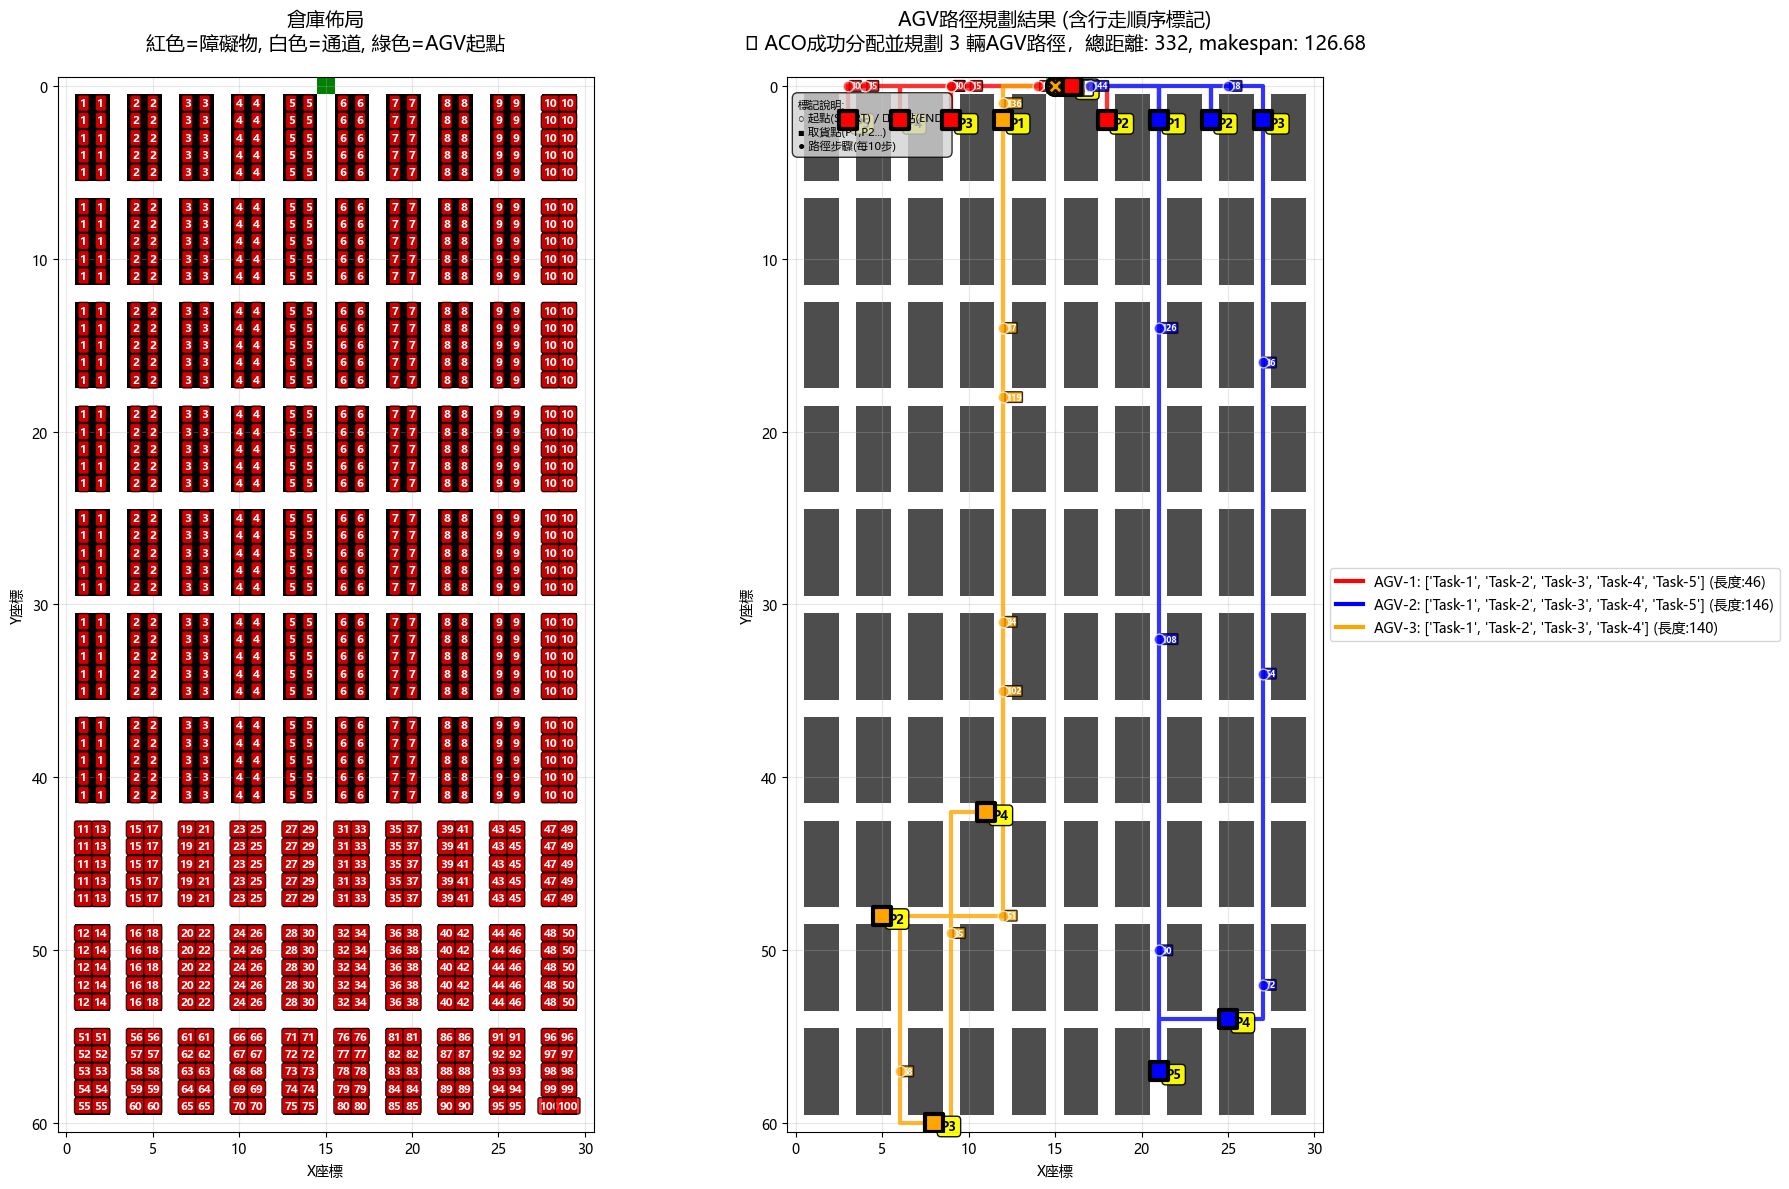


🎨 創建分階段任務執行視覺化...
   ℹ️  沒有AGV需要分批執行（所有AGV任務數≤5）

📤 步驟6: 匯出結果
📤 正在匯出路徑到 routes_for_flexsim.csv...
✅ 成功匯出 349 筆路徑資料到 routes_for_flexsim.csv

📋 匯出資料預覽:
AGV_ID                              Order  Step  X  Y        Action
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   1.0 15  0          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   2.0 16  0          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   2.5 16  0 PICKUP_Item-1
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   3.0 17  0          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   4.0 18  0          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   5.0 18  1          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   6.0 18  2          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   6.5 18  2 PICKUP_Item-2
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   7.0 18  1          MOVE
 AGV-1 Task-1,Task-2,Task-3,Task-4,Task-5   8.0 18  0          MOVE
📤 正在匯出倉庫佈局到 warehouse_layout.csv...
✅ 成功匯出倉庫佈局資料到 warehouse_layout.csv

🎉 AGV倉庫路線規劃演示完成！
🎯 ACO最優makes

In [12]:
# 執行完整的AGV路線規劃演示 - 使用ACO動態任務分配與ABC分類訂單
print("🎯 演示 ACO 動態任務分配系統 (ABC分類訂單 - 前兩筆訂單測試)")
print("="*60)

# 1. 生成ABC分類訂單
print("📊 步驟1: 生成ABC分類訂單")
all_orders = generate_orders(num_orders=100, items_per_order=10)
print(f"✅ 生成了 {len(all_orders)} 個訂單")

# 取前兩筆訂單進行測試
first_two_orders = all_orders[:2]
print(f"\n📋 測試用前兩筆訂單:")
for i, order in enumerate(first_two_orders, 1):
    print(f"   訂單 {i}: {order}")

# 分析前兩筆訂單的ABC分布
print(f"\n📊 前兩筆訂單ABC分析:")
two_orders_distribution = analyze_order_distribution(first_two_orders)

# 2. 將前兩筆訂單轉換為唯一任務列表
combined_items = []
for order in first_two_orders:
    combined_items.extend(order)

unique_task_items = list(set(combined_items))  # 去重
unique_task_items.sort(key=lambda x: int(x))  # 按數字排序
print(f"\n🎯 前兩筆訂單合併包含 {len(unique_task_items)} 個唯一任務")
print(f"   任務列表: {unique_task_items}")

# 3. 執行ACO任務分配 (使用前兩筆訂單的任務)
print(f"\n🤖 使用3台AGV分配前兩筆訂單的 {len(unique_task_items)} 個任務")
print("⚠️  注意：每台AGV執行5個任務後必須返回起點(15,0)")
warehouse, results = run_complete_agv_demo(
    csv_file='warehouse.csv',
    depot=(15, 0),  # AGV起始位置 (15,0)
    all_task_items=unique_task_items,  # 使用前兩筆訂單的任務
    num_agvs=3,      # AGV數量
    use_aco_allocation=True,  # 使用ACO動態分配
    visualize=True,   # 顯示視覺化
    export=True       # 匯出結果
)

print("\n" + "="*60)
print("🔄 比較: 傳統固定分配方式 (使用前兩筆訂單)")
print("="*60)

# 為了公平比較，將前兩筆訂單的任務平均分配給3台AGV
task_count = len(unique_task_items)
if task_count >= 3:
    tasks_per_agv = task_count // 3
    remainder = task_count % 3

    fixed_orders = []
    start_idx = 0
    for i in range(3):
        end_idx = start_idx + tasks_per_agv + (1 if i < remainder else 0)
        agv_tasks = unique_task_items[start_idx:end_idx]
        fixed_orders.append(agv_tasks)
        start_idx = end_idx
else:
    # 如果任務數少於3個，直接分配
    fixed_orders = [[task] for task in unique_task_items]
    # 補充空訂單給剩餘的AGV
    while len(fixed_orders) < 3:
        fixed_orders.append([])

print(f"📌 固定分配方案 (基於前兩筆訂單):")
for i, order in enumerate(fixed_orders, 1):
    if order:
        print(f"   AGV-{i}: {len(order)} 個任務 {order}")
    else:
        print(f"   AGV-{i}: 0 個任務 []")

# 比較：傳統固定分配方式
warehouse2, results2 = run_complete_agv_demo(
    csv_file='warehouse.csv',
    depot=(15, 0),  # 修正為(15,0)
    orders=fixed_orders,  # 使用平均分配的任務
    use_aco_allocation=False,  # 使用固定分配
    visualize=False,  # 不重複顯示視覺化
    export=False      # 不重複匯出
)

# 性能比較
if results and results2 and results['success'] and results2['success']:
    print("\n" + "🏆 前兩筆ABC訂單系統性能比較結果")
    print("="*60)
    print(f"🎯 ACO動態分配 (前兩筆訂單，任務數: {len(unique_task_items)}):")
    print(f"   - 總路徑距離: {results['total_distance']}")
    if 'aco_makespan' in results:
        print(f"   - ACO Makespan: {results['aco_makespan']:.2f}")
    print(f"   - 成功率: {'100%' if results['success'] else '部分失敗'}")
    print(f"   - 每5個任務返回起點(15,0)規則: 已啟用")
    
    print(f"\n📌 固定平均分配 (前兩筆訂單，任務數: {len(unique_task_items)}):")
    print(f"   - 總路徑距離: {results2['total_distance']}")
    print(f"   - 成功率: {'100%' if results2['success'] else '部分失敗'}")
    
    if results2['total_distance'] > 0:
        improvement = ((results2['total_distance'] - results['total_distance']) / results2['total_distance']) * 100
        print(f"\n💡 ACO優化效果:")
        print(f"   - 路徑距離改善: {improvement:.1f}%")
        print(f"   - 基於前兩筆訂單的 {len(unique_task_items)} 個任務比較")
        print(f"   - 前兩筆訂單內容: {first_two_orders}")
    else:
        print(f"\n⚠️  無法計算改善程度（固定分配失敗）")
    print("="*60)
else:
    print("\n⚠️  無法進行性能比較（某個方法失敗）")
    if results:
        print(f"   ACO結果: {'成功' if results['success'] else '失敗'}")
    if results2:
        print(f"   固定分配結果: {'成功' if results2['success'] else '失敗'}")

## 🔧 ABC分類系統自訂測試區域

您可以在此區域進行ABC分類訂單系統的自訂測試和調整

In [13]:
# ABC分類系統自訂測試

print("\n🧪 自訂測試: ABC分類小規模測試")
print("="*40)

if 'warehouse' in locals() and warehouse is not None:
    # 生成少量訂單進行測試
    small_test_orders = generate_orders(num_orders=5, items_per_order=6)
    small_tasks = convert_orders_to_tasks(small_test_orders)
    
    print(f"📊 小規模測試訂單:")
    for idx, order in enumerate(small_test_orders, 1):
        print(f"   訂單 {idx}: {order}")
    
    print(f"\n🎯 轉換為 {len(small_tasks)} 個唯一任務: {small_tasks}")
    
    # 分析小測試的ABC分布
    small_distribution = analyze_order_distribution(small_test_orders)
    
    # 使用ACO分配測試
    print(f"\n🤖 使用2台AGV進行ACO任務分配測試...")
    small_result = plan_agv_routes_with_aco_allocation(
        warehouse, 
        small_tasks, 
        num_agvs=2,  # 使用2台AGV測試
        depot=(15, 0)
    )
    
    if small_result['success']:
        print("✅ 小規模ABC分類測試成功")
        print(f"   ACO Makespan: {small_result.get('aco_makespan', 'N/A')}")
        print(f"   總路徑距離: {small_result['total_distance']}")
        
        # 顯示任務分配詳情
        for agv_name, alloc_info in small_result.get('task_allocation', {}).items():
            print(f"   {agv_name}: {alloc_info['num_tasks']} 個任務 {alloc_info.get('task_indices', [])}")
    else:
        print("❌ 小規模ABC分類測試失敗")
        print(f"   錯誤: {small_result.get('message', 'Unknown error')}")
else:
    print("⚠️  請先執行主要演示以載入倉庫數據")
        
print("="*40)

# 進階測試：比較不同訂單規模的影響
print("\n🔬 進階測試: 不同訂單規模比較")
print("="*40)

if 'warehouse' in locals() and warehouse is not None:
    test_scales = [
        (10, 5),   # 10個訂單，每個5件物品
        (20, 8),   # 20個訂單，每個8件物品
        (50, 12)   # 50個訂單，每個12件物品
    ]
    
    for num_orders, items_per_order in test_scales:
        print(f"\n📊 測試規模: {num_orders}個訂單 × {items_per_order}件物品")
        
        scale_orders = generate_orders(num_orders, items_per_order)
        scale_tasks = convert_orders_to_tasks(scale_orders)
        
        print(f"   生成 {len(scale_tasks)} 個唯一任務")
        
        # 快速分析（不顯示詳細）
        total_items = num_orders * items_per_order
        a_count = sum(1 for order in scale_orders for item in order if 1 <= int(item) <= 10)
        a_percentage = (a_count / total_items) * 100
        
        print(f"   A類物品占比: {a_percentage:.1f}% (預期70%)")
        print(f"   適合 {min(3, len(scale_tasks))} 台AGV分配")

print("="*40)


🧪 自訂測試: ABC分類小規模測試
📊 小規模測試訂單:
   訂單 1: ['4', '3', '2', '2', '7', '8']
   訂單 2: ['4', '53', '4', '9', '1', '8']
   訂單 3: ['32', '5', '3', '46', '55', '42']
   訂單 4: ['2', '5', '7', '5', '9', '6']
   訂單 5: ['1', '10', '2', '3', '9', '56']

🎯 轉換為 16 個唯一任務: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '32', '42', '46', '53', '55', '56']
📊 訂單分析結果:
   總物品數: 30
   A類物品: 24 件 (80.0%)
   B類物品: 3 件 (10.0%)
   C類物品: 3 件 (10.0%)

🤖 使用2台AGV進行ACO任務分配測試...
🚚 開始使用ACO為 2 輛AGV分配並規劃 16 個任務...
🎯 開始使用ACO分配 16 個任務給 2 台AGV...
   ✅ 生成了 16 個任務取貨位置
   🐜 執行 100 次ACO迭代...
      迭代 0: 當前最佳makespan = 172.05
      迭代 20: 當前最佳makespan = 143.22
      迭代 40: 當前最佳makespan = 143.22
      迭代 60: 當前最佳makespan = 143.22
      迭代 80: 當前最佳makespan = 143.22
   ✅ ACO分配完成! 最佳makespan: 143.22
✅ ACO任務分配完成，makespan: 143.22

🚛 AGV-1 分配到 8 個任務位置
   ⚠️  任務數量(8)超過5個，將分批執行，每批5個任務後返回起點
   📦 處理第 1 批任務: 5 個任務
   📦 處理第 2 批任務: 3 個任務
❌ 錯誤: cannot access local variable 'path_valid' where it is not associated with a value

❌ ACO任務分配失敗: c